In [1]:
import os
import json
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import mobilenet_v3_large

from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, roc_curve

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================
# PATHS
# ===============================
BASE_PATH = "/kaggle/input/datasets/iharshsinha/deepfashion2-top5-processed/processed"

VAL_IMAGES = os.path.join(BASE_PATH, "validation/images")
VAL_ANNOS  = os.path.join(BASE_PATH, "validation/annos")

MODEL_PATH = "/kaggle/input/models/ayushmishra0180/mobilenetscratch/pytorch/default/1/mobilenetv3_multilabel_scratch.pth"

# ===============================
# LABEL MAP
# ===============================
LABEL_MAP = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}

INV_LABEL_MAP = {v:k for k,v in LABEL_MAP.items()}
NUM_CLASSES = 5

Device: cuda


In [2]:
class FashionDataset(Dataset):

    def __init__(self, annos_dir, images_dir, transform):
        self.files = [f for f in os.listdir(annos_dir) if f.endswith(".json")]
        self.annos_dir = annos_dir
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        file = self.files[idx]

        with open(os.path.join(self.annos_dir,file)) as f:
            data = json.load(f)

        labels = np.zeros(NUM_CLASSES)

        for k,v in data.items():
            if k.startswith("item"):
                cat = v["category_name"]
                if cat in LABEL_MAP:
                    labels[LABEL_MAP[cat]] = 1

        img_path = os.path.join(self.images_dir, file.replace(".json",".jpg"))
        img = Image.open(img_path).convert("RGB")

        img = self.transform(img)

        return img, torch.tensor(labels, dtype=torch.float32)


# ===============================
# TRANSFORM
# ===============================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

val_loader = DataLoader(
    FashionDataset(VAL_ANNOS, VAL_IMAGES, transform),
    batch_size=64,
    shuffle=False,
    num_workers=2
)

# ===============================
# LOAD MODEL
# ===============================
model = mobilenet_v3_large(weights=None)

# IMPORTANT LAYER CHANGE
model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

print("MobileNetV3 Scratch model loaded successfully")

MobileNetV3 Scratch model loaded successfully


Evaluating: 100%|██████████| 371/371 [05:31<00:00,  1.12it/s]



Category              | Precision | Recall | F1-score
-------------------------------------------------------
short sleeve top       | 0.8217 | 0.7845 | 0.8027
trousers               | 0.8201 | 0.8916 | 0.8544
shorts                 | 0.5806 | 0.8001 | 0.6729
long sleeve top        | 0.5816 | 0.7767 | 0.6652
skirt                  | 0.6784 | 0.8301 | 0.7467
-------------------------------------------------------
Macro F1: 0.7484 | Micro F1: 0.7666


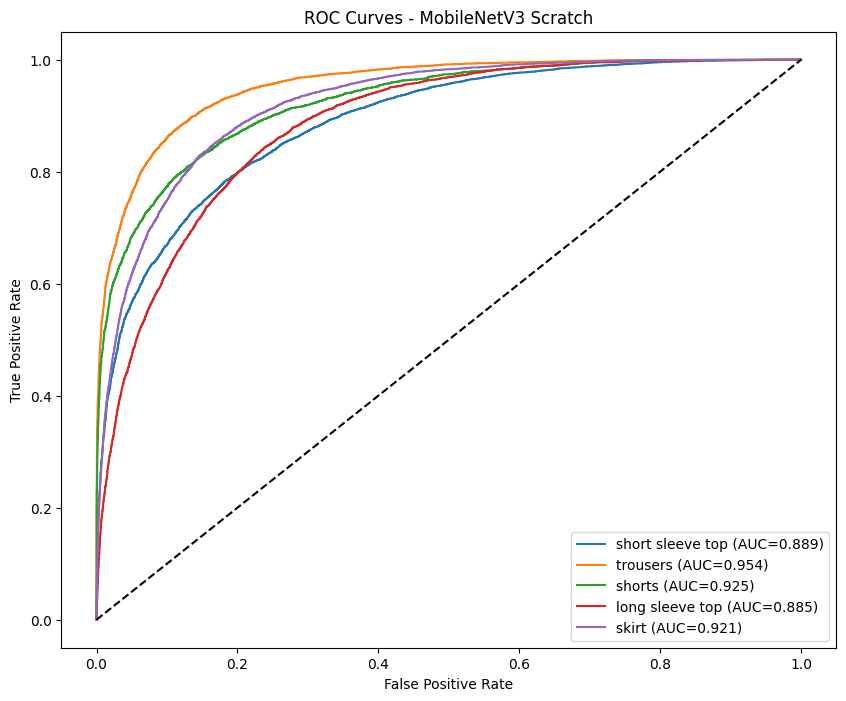

In [3]:
all_targets = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating"):

        images = images.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(float)

        all_targets.extend(targets.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

all_targets = np.array(all_targets)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# ===============================
# METRICS
# ===============================
precision, recall, f1, _ = precision_recall_fscore_support(
    all_targets, all_preds, average=None
)

macro_f1 = precision_recall_fscore_support(all_targets, all_preds, average="macro")[2]
micro_f1 = precision_recall_fscore_support(all_targets, all_preds, average="micro")[2]

print("\nCategory              | Precision | Recall | F1-score")
print("-"*55)

for i in range(NUM_CLASSES):
    print(f"{INV_LABEL_MAP[i]:<22} | {precision[i]:.4f} | {recall[i]:.4f} | {f1[i]:.4f}")

print("-"*55)
print(f"Macro F1: {macro_f1:.4f} | Micro F1: {micro_f1:.4f}")

# ===============================
# ROC CURVES
# ===============================
plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(all_targets[:,i], all_probs[:,i])
    auc_score = roc_auc_score(all_targets[:,i], all_probs[:,i])

    plt.plot(fpr, tpr, label=f"{INV_LABEL_MAP[i]} (AUC={auc_score:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - MobileNetV3 Scratch")
plt.legend()
plt.show()